In [1]:
import pandas as pd
import matplotlib.pyplot as plt 
import numpy as np
import os
import sys
import seaborn as sns
import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize 
import re
import string
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer
from textblob import TextBlob
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
from wordcloud import WordCloud
from sklearn.feature_extraction.text import TfidfVectorizer
import warnings
warnings.filterwarnings('ignore')
nltk.download('stopwords', quiet = True)
nltk.download('punkt', quiet = True)
nltk.download('punkt_tab', quiet = True)

plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 12
sns.set_theme(style='darkgrid')

print("All libraries imported successfully!")


All libraries imported successfully!


In [2]:
print("Loading dataset...")

df_raw = pd.read_csv('../data/raw/reviews.csv')

print(f"Dataset loaded successfully!")
print(f"Rows loaded : {df_raw.shape[0]:,}")
print(f"   Columns:        {df_raw.shape[1]}")
print(f"   Memory usage:   "
      f" {df_raw.memory_usage(deep = True).sum() / 1024**2:.2f} MB")

print("\nFIRST 3 ROWS:")
print("─" * 45)
display(df_raw.head(3))

print("\nCOLUMN INFO:")
print("─" * 45)
display(df_raw.info())

Loading dataset...
Dataset loaded successfully!
Rows loaded : 568,454
   Columns:        10
   Memory usage:    313.06 MB

FIRST 3 ROWS:
─────────────────────────────────────────────


,Id,ProductId,UserId,ProfileName,HelpfulnessNumerator,HelpfulnessDenominator,Score,Time,Summary,Text
0,1,B001E4KFG0,A3SGXH7AUHU8GW,delmartian,1,1,5,1303862400,Good Quality Dog Food,I have bought several of the Vitality canned d...
1,2,B00813GRG4,A1D87F6ZCVE5NK,dll pa,0,0,1,1346976000,Not as Advertised,Product arrived labeled as Jumbo Salted Peanut...
2,3,B000LQOCH0,ABXLMWJIXXAIN,"Natalia Corres ""Natalia Corres""",1,1,4,1219017600,"""Delight"" says it all",This is a confection that has been around a fe...



COLUMN INFO:
─────────────────────────────────────────────
<class 'pandas.DataFrame'>
RangeIndex: 568454 entries, 0 to 568453
Data columns (total 10 columns):
 #   Column                  Non-Null Count   Dtype
---  ------                  --------------   -----
 0   Id                      568454 non-null  int64
 1   ProductId               568454 non-null  str  
 2   UserId                  568454 non-null  str  
 3   ProfileName             568428 non-null  str  
 4   HelpfulnessNumerator    568454 non-null  int64
 5   HelpfulnessDenominator  568454 non-null  int64
 6   Score                   568454 non-null  int64
 7   Time                    568454 non-null  int64
 8   Summary                 568427 non-null  str  
 9   Text                    568454 non-null  str  
dtypes: int64(5), str(5)
memory usage: 313.1 MB


None

In [3]:
print("DATASET OVERVIEW")
print("=" * 50)

print("\n SCORE (STAR RATING) DISTRIBUTION:")
print("─" * 40)
score_counts = df_raw['Score'].value_counts().sort_index()

for star, count in score_counts.items():

    percentage = count / len(df_raw) * 100
    bar = '⭐' * star
    print(f'{bar} {star} stars:'
          f'{count:,} reviews ({percentage:.2f}%)')
    
print("\n MISSING VALUES:")
print("─" * 40)
missing = df_raw.isnull().sum()

for col, count in missing.items():
    if count > 0:
        pct = count / len(df_raw) * 100
        print(f"{col}: {count:,} missing values ({pct:.2f}%)")
    else:
        print(f"   {col}: No missing values")

print("\n REVIEW TEXT STATISTICS:")
print("─" * 40)
df_raw['text_length'] = df_raw['Text'].str.len()
df_raw['word_count'] = df_raw['Text'].str.split().str.len()

print(f"   Average review length: "
      f"{df_raw['text_length'].mean():.0f} characters")
print(f"   Average word count:    "
      f"{df_raw['word_count'].mean():.0f} words")
print(f"   Shortest review:       "
      f"{df_raw['text_length'].min()} characters")
print(f"   Longest review:        "
      f"{df_raw['text_length'].max():,} characters")

print("\n SAMPLE REVIEWS:")
print("─" * 40)

for score in [1, 3, 5]:

    sample = df_raw[df_raw['Score'] == score]['Text'].iloc[0]

    print(f"\n   ⭐ {score}-star review:")
    print(f"   '{sample[:150]}...'")

DATASET OVERVIEW

 SCORE (STAR RATING) DISTRIBUTION:
────────────────────────────────────────
⭐ 1 stars:52,268 reviews (9.19%)
⭐⭐ 2 stars:29,769 reviews (5.24%)
⭐⭐⭐ 3 stars:42,640 reviews (7.50%)
⭐⭐⭐⭐ 4 stars:80,655 reviews (14.19%)
⭐⭐⭐⭐⭐ 5 stars:363,122 reviews (63.88%)

 MISSING VALUES:
────────────────────────────────────────
   Id: No missing values
   ProductId: No missing values
   UserId: No missing values
ProfileName: 26 missing values (0.00%)
   HelpfulnessNumerator: No missing values
   HelpfulnessDenominator: No missing values
   Score: No missing values
   Time: No missing values
Summary: 27 missing values (0.00%)
   Text: No missing values

 REVIEW TEXT STATISTICS:
────────────────────────────────────────


   Average review length: 436 characters
   Average word count:    80 words
   Shortest review:       12 characters
   Longest review:        21,409 characters

 SAMPLE REVIEWS:
────────────────────────────────────────

   ⭐ 1-star review:
   'Product arrived labeled as Jumbo Salted Peanuts...the peanuts were actually small sized unsalted. Not sure if this was an error or if the vendor inten...'

   ⭐ 3-star review:
   'This seems a little more wholesome than some of the supermarket brands, but it is somewhat mushy and doesn't have quite as much flavor either.  It did...'

   ⭐ 5-star review:
   'I have bought several of the Vitality canned dog food products and have found them all to be of good quality. The product looks more like a stew than ...'


In [4]:
# Cell 4 — Convert Unix Timestamp to Date

print("CONVERTING TIMESTAMP TO READABLE DATE")
print("─" * 45)

print(f"Sample BEFORE conversion:")
print(f"   {df_raw['Time'].iloc[0]}")

df_raw['Date'] = pd.to_datetime(df_raw['Time'], unit='s')

df_raw['Year'] = df_raw['Date'].dt.year

df_raw['Month'] = df_raw['Date'].dt.month

df_raw['YearMonth'] = df_raw['Date'].dt.to_period('M')

print(f"\nSample AFTER conversion:")
print(f"   Date:      {df_raw['Date'].iloc[0]}")
print(f"   Year:      {df_raw['Year'].iloc[0]}")
print(f"   Month:     {df_raw['Month'].iloc[0]}")
print(f"   YearMonth: {df_raw['YearMonth'].iloc[0]}")

print(f"\nDate range of reviews:")
print(f"   Earliest: {df_raw['Date'].min().strftime('%B %Y')}")

print(f"   Latest:   {df_raw['Date'].max().strftime('%B %Y')}")
print(f"\n Date conversion complete!")

CONVERTING TIMESTAMP TO READABLE DATE
─────────────────────────────────────────────
Sample BEFORE conversion:
   1303862400

Sample AFTER conversion:
   Date:      2011-04-27 00:00:00
   Year:      2011
   Month:     4
   YearMonth: 2011-04

Date range of reviews:
   Earliest: October 1999
   Latest:   October 2012

 Date conversion complete!


In [5]:
# Cell 5 — Calculating Helpfulness Ratio

print("CALCULATING HELPFULNESS RATIO")
print("─" * 45)

df_raw['helpfulness_ratio'] = (
    df_raw['HelpfulnessNumerator'] /
    df_raw['HelpfulnessDenominator'].replace(0, 1))

print(f"Average helpfulness: "
      f"{df_raw['helpfulness_ratio'].mean():.2f}")
print(f"Reviews with votes: "
      f"{(df_raw['HelpfulnessDenominator'] > 0).sum():,}")
print(f"Reviews with no votes: "
      f"{(df_raw['HelpfulnessDenominator'] == 0).sum():,}")
print("Helpfulness ratio calculated!")


CALCULATING HELPFULNESS RATIO
─────────────────────────────────────────────
Average helpfulness: 0.41
Reviews with votes: 298,402
Reviews with no votes: 270,052
Helpfulness ratio calculated!


In [6]:
# Cell 6 — Text Preprocessing

ENGLISH_STOPWORDS = set(stopwords.words('english'))

print(f"   Number of English stopwords: "
      f"{len(ENGLISH_STOPWORDS)}")

# FUNCTION 1: Minimal cleaning for VADER
def clean_for_vader(text):
    """
    Minimal cleaning for VADER sentiment analysis.

    KEEPS (because VADER uses these for scoring):
        Capitalization → "AMAZING" scores higher
        Exclamation marks → "great!!!" scores higher
        Emoticons → :) scores positive
        Question marks → signal uncertainty
        All punctuation → part of emotional signal

    REMOVES (no sentiment value):
        URLs → http://... adds nothing
        HTML tags → <br> adds nothing
        Extra whitespace → formatting only

    Parameters:
    -----------
    text : str
        One raw review string from the dataset

    Returns:
    --------
    str : Minimally cleaned text
    """
    if not isinstance(text, str):

        return ""
    
    text = re.sub(r'http\S+|www\S+', '', text)
    text = re.sub(r'<.*?>', ' ', text)
    text = ' '.join(text.split())

    return text.strip()

# FUNCTION 2: Maximum cleaning for WordCloud/TF-IDF
def clean_for_wordcloud(text):
    """
    Maximum cleaning for WordCloud and TF-IDF.

    We want ONLY meaningful words.
    Word clouds visualize word FREQUENCY.
    TF-IDF finds most IMPORTANT words.

    Neither tool benefits from punctuation,
    numbers, stopwords, or capitalization.
    Including them creates noise in our visuals!

    REMOVES everything:
        URLs
        HTML tags
        Punctuation (!, ?, ., ,)
        Numbers (5, 100, 2024)
        Stopwords (the, is, and, a)
        Short words (2 characters or less)

    KEEPS only:
        Meaningful lowercase words

    Parameters:
    -----------
    text : str
        One raw review string

    Returns:
    --------
    str : Space-separated meaningful words
          Example: "amazing battery life excellent"
    """

    if not isinstance(text, str):

        return ""
    
    text = text.lower()
    text = re.sub(r'http\S+|www\S+', '', text)
    text = re.sub(r'<.*?>', ' ', text)
    text = re.sub(r'[^\w\s]', '', text)
    text = re.sub(r'\d+', '', text)
    text = ' '.join(text.split())

    tokens = word_tokenize(text)
    tokens = [
        word 
        for word in tokens
        if word not in ENGLISH_STOPWORDS and len(word) > 2
    ]
    return ' '.join(tokens)

test_review = (
    "This product is ABSOLUTELY AMAZING!!! "
    "Best purchase I've EVER made :) :) "
    "Visit http://amazon.com for details. "
    "5/5 stars. Would DEFINITELY recommend!!!"
)

print("\nORIGINAL REVIEW:")
print(f"'{test_review}'")

print("\n" + "─" * 50)
print("AFTER clean_for_vader():")
print(f"'{clean_for_vader(test_review)}'")
print("Notice: CAPS kept  !!! kept  :) kept ")

print("\n" + "─" * 50)
print("AFTER clean_for_wordcloud():")
print(clean_for_wordcloud(test_review))
print("Notice: only meaningful words remain ")

   Number of English stopwords: 198

ORIGINAL REVIEW:
'This product is ABSOLUTELY AMAZING!!! Best purchase I've EVER made :) :) Visit http://amazon.com for details. 5/5 stars. Would DEFINITELY recommend!!!'

──────────────────────────────────────────────────
AFTER clean_for_vader():
'This product is ABSOLUTELY AMAZING!!! Best purchase I've EVER made :) :) Visit for details. 5/5 stars. Would DEFINITELY recommend!!!'
Notice: CAPS kept  !!! kept  :) kept 

──────────────────────────────────────────────────
AFTER clean_for_wordcloud():
product absolutely amazing best purchase ive ever made visit details stars would definitely recommend
Notice: only meaningful words remain 


In [7]:
# Cell 7 — Apply Cleaning to All dataset Reviews

# Apply VADER cleaning
import time

print("Applying cleaning to all reviews...")
print("─" * 45)

start_time = time.time()

df_raw['text_for_vader'] = df_raw['Text'].apply(
    clean_for_vader
)

time_taken = time.time() - start_time

print(f"VADER cleaning completed! "
      f"({time_taken:.1f} seconds)")

# Apply WordCloud cleaning
start_time = time.time()

df_raw['text_for_wordcloud'] = df_raw['Text'].apply(
    clean_for_wordcloud
)

time_taken = time.time() - start_time

print(f"WordCloud cleaning completed! "
      f"({time_taken:.1f} seconds)")

print("\nVERIFICATION — Same review, both versions:")
print("─" * 50)

# Verify results on one example review
example_idx = 5

print("ORIGINAL:")
original = df_raw['Text'].iloc[example_idx]
print(f"'{original[:200]}...'")

print("\nFOR VADER:")
vader_version = df_raw['text_for_vader'].iloc[example_idx]
print(f"'{vader_version[:200]}...'")

print("\nFOR WORDCLOUD:")
wc_version = df_raw['text_for_wordcloud'].iloc[example_idx]
print(f"'{wc_version[:200]}...'")

print(f"\nDataset shape now: {df_raw.shape}")

Applying cleaning to all reviews...
─────────────────────────────────────────────
VADER cleaning completed! (8.0 seconds)
WordCloud cleaning completed! (180.9 seconds)

VERIFICATION — Same review, both versions:
──────────────────────────────────────────────────
ORIGINAL:
'I got a wild hair for taffy and ordered this five pound bag. The taffy was all very enjoyable with many flavors: watermelon, root beer, melon, peppermint, grape, etc. My only complaint is there was a ...'

FOR VADER:
'I got a wild hair for taffy and ordered this five pound bag. The taffy was all very enjoyable with many flavors: watermelon, root beer, melon, peppermint, grape, etc. My only complaint is there was a ...'

FOR WORDCLOUD:
'got wild hair taffy ordered five pound bag taffy enjoyable many flavors watermelon root beer melon peppermint grape etc complaint bit much redblack licoriceflavored pieces particular favorites kids hu...'

Dataset shape now: (568454, 19)


In [8]:
# Cell 8 — VADER Sentiment Analysis

print("TESTING VADER")
print("=" * 50)

analyzer = SentimentIntensityAnalyzer()

test_reviews = [
    "This product is absolutely AMAZING!!!",
    "Terrible quality. Complete waste of money!",
    "It is okay. Nothing special.",
    "I LOVE this! Works perfectly!!!",
    "not bad, not great either"
]

print("\nSAMPLE TESTS:")
print("─" * 50)

for review in test_reviews:
    scores  = analyzer.polarity_scores(review)
    compound = scores['compound']
    if compound >= 0.05:
        label = "POSITIVE"
    elif compound <= -0.05:
        label = "NEGATIVE"
    else:
        label = "NEUTRAL"

    print(f"Review: '{review}'")
    print(f"  Compound: {compound:+.3f} → {label}")
    print()

print("─" * 50)
print("Notice:")
print("'AMAZING!!!' → high positive (caps + !!!)")
print("'LOVE' + '!!!' → even higher")
print("This is why we preserved caps and !!! for VADER!")    

TESTING VADER

SAMPLE TESTS:
──────────────────────────────────────────────────
Review: 'This product is absolutely AMAZING!!!'
  Compound: +0.772 → POSITIVE

Review: 'Terrible quality. Complete waste of money!'
  Compound: -0.735 → NEGATIVE

Review: 'It is okay. Nothing special.'
  Compound: -0.092 → NEGATIVE

Review: 'I LOVE this! Works perfectly!!!'
  Compound: +0.906 → POSITIVE

Review: 'not bad, not great either'
  Compound: +0.675 → POSITIVE

──────────────────────────────────────────────────
Notice:
'AMAZING!!!' → high positive (caps + !!!)
'LOVE' + '!!!' → even higher
This is why we preserved caps and !!! for VADER!


In [9]:
# Cell 9 — Apply VADER to All dataset Reviews

print("Applying VADER to all reviews...")
print("─" * 45)

start_time = time.time()

all_vader_scores = df_raw['text_for_vader'].apply(
    analyzer.polarity_scores
)

elapsed = time.time() - start_time

print(f" VADER scoring complete! ({elapsed:.1f}s)")

df_raw['vader_compound'] = all_vader_scores.apply(
    lambda x: x['compound']
)

df_raw['vader_pos'] = all_vader_scores.apply(
    lambda x: x['pos']
)

df_raw['vader_neg'] = all_vader_scores.apply(
    lambda x: x['neg']
)

df_raw['vader_neu'] = all_vader_scores.apply(
    lambda x: x['neu']
)

print("Scores extracted into columns!")

def assign_vader_label(compound_score):
    """
    Converts VADER compound score to text label.

    Parameters:
    -----------
    compound_score : float
        VADER compound score between -1 and +1

    Returns:
    --------
    str : 'POSITIVE', 'NEGATIVE', or 'NEUTRAL'
    """
    if compound_score >= 0.05:
        return 'POSITIVE'
    elif compound_score <= -0.05:
        return 'NEGATIVE'
    else:
        return 'NEUTRAL'

df_raw['sentiment'] = df_raw['vader_compound'].apply(
    assign_vader_label
)

print("Sentiment labels assigned!")

print("\nVADER SENTIMENT DISTRIBUTION:")
print("─" * 40)

label_counts = df_raw['sentiment'].value_counts()

total = len(df_raw)

for label, count in label_counts.items():
    percentage = (count / total) * 100
    bar = '█' * int(percentage / 2)
    print(f"  {label:<10} {count:>8,}  "
          f"({percentage:>5.1f}%)  {bar}")

Applying VADER to all reviews...
─────────────────────────────────────────────
 VADER scoring complete! (375.9s)
Scores extracted into columns!
Sentiment labels assigned!

VADER SENTIMENT DISTRIBUTION:
────────────────────────────────────────
  POSITIVE    501,284  ( 88.2%)  ████████████████████████████████████████████
  NEGATIVE     55,709  (  9.8%)  ████
  NEUTRAL      11,461  (  2.0%)  █


In [10]:
# Cell 10 — TextBlob Sentiment Analysis

print("TESTING TEXTBLOB")
print("=" * 50)

for review in test_reviews:
    blob = TextBlob(review)
    polarity = blob.sentiment.polarity
    subjectivity = blob.sentiment.subjectivity
    print(f"'{review[:45]}...'")
    print(f"  Polarity: {polarity:+.3f}  "
          f"Subjectivity: {subjectivity:.3f}")
    print()

print("─" * 50)

print("\nApplying TextBlob to all reviews...")

start_time = time.time()

def get_textblob_scores(text):
    """
    Gets TextBlob polarity and subjectivity scores.

    Parameters:
    -----------
    text : str
        One review string (cleaned)

    Returns:
    --------
    tuple : (polarity, subjectivity)
        polarity = float -1.0 to +1.0
        subjectivity = float 0.0 to 1.0
    """

    if not isinstance(text, str) or text.strip() == "":
        return (0.0, 0.0)
    blob = TextBlob(text)
    return (
        blob.sentiment.polarity,
        blob.sentiment.subjectivity
    )
 
tb_results = df_raw['text_for_vader'].apply(
    get_textblob_scores
)

df_raw['tb_polarity'] = tb_results.apply(lambda x: x[0])

df_raw['tb_subjectivity'] = tb_results.apply(lambda x: x[1])

def assign_textblob_label(polarity):
    """Converts TextBlob polarity to label."""
    if polarity > 0.05:
        return 'POSITIVE'
    elif polarity < -0.05:
        return 'NEGATIVE'
    else:
        return 'NEUTRAL'

df_raw['tb_label'] = df_raw['tb_polarity'].apply(
    assign_textblob_label
)

elapsed = time.time() - start_time
print(f"TextBlob complete! ({elapsed:.1f}s)")

print("\nTEXTBLOB SENTIMENT DISTRIBUTION:")
print("─" * 40)
tb_counts = df_raw['tb_label'].value_counts()
for label, count in tb_counts.items():
    pct = (count / len(df_raw)) * 100
    print(f"  {label:<10} {count:>8,}  ({pct:>5.1f}%)")

print(f"\nSUBJECTIVITY INSIGHT:")
avg_subj = df_raw['tb_subjectivity'].mean()
print(f"  Average subjectivity: {avg_subj:.3f}")
print(f"  Meaning: reviews are mostly "
      f"{'subjective opinions' if avg_subj > 0.5 else 'objective facts'}")

TESTING TEXTBLOB
'This product is absolutely AMAZING!!!...'
  Polarity: +1.000  Subjectivity: 0.900

'Terrible quality. Complete waste of money!...'
  Polarity: -0.383  Subjectivity: 0.467

'It is okay. Nothing special....'
  Polarity: +0.429  Subjectivity: 0.536

'I LOVE this! Works perfectly!!!...'
  Polarity: +0.812  Subjectivity: 0.800

'not bad, not great either...'
  Polarity: -0.025  Subjectivity: 0.708

──────────────────────────────────────────────────

Applying TextBlob to all reviews...
TextBlob complete! (247.9s)

TEXTBLOB SENTIMENT DISTRIBUTION:
────────────────────────────────────────
  POSITIVE    473,529  ( 83.3%)
  NEUTRAL      55,316  (  9.7%)
  NEGATIVE     39,609  (  7.0%)

SUBJECTIVITY INSIGHT:
  Average subjectivity: 0.550
  Meaning: reviews are mostly subjective opinions


In [11]:
# Cell 11 — Validate Results Against Star Ratings

print("VALIDATING SENTIMENT AGAINST STAR RATINGS")
print("=" * 55)

def star_to_label(score):
    """
    Converts 1-5 star rating to sentiment label.

    Parameters:
    -----------
    score : int
        Star rating (1, 2, 3, 4, or 5)

    Returns:
    --------
    str : 'POSITIVE', 'NEUTRAL', or 'NEGATIVE'
    """
    if score >= 4:
        return 'POSITIVE'
    elif score == 3:
        return 'NEUTRAL'
    else:
        return 'NEGATIVE'

df_raw['rating_label'] = df_raw['Score'].apply(
    star_to_label
)

vader_accuracy = (
    df_raw['sentiment'] == df_raw['rating_label']
).mean() * 100

tb_accuracy = (
    df_raw['tb_label'] == df_raw['rating_label']
).mean() * 100

print(f"\nACCURACY VS STAR RATINGS:")
print(f"─" * 40)
print(f"  VADER accuracy:    {vader_accuracy:.1f}%")
print(f"  TextBlob accuracy: {tb_accuracy:.1f}%")

print(f"\nDISTRIBUTION COMPARISON:")
print(f"{'':─<55}")
print(f"{'Label':<12} {'Star Rating':>12} "
      f"{'VADER':>10} {'TextBlob':>10}")
print(f"{'':─<55}")

for label in ['POSITIVE', 'NEUTRAL', 'NEGATIVE']:
    rating_pct = (
        df_raw['rating_label'] == label
    ).mean() * 100

    vader_pct = (
        df_raw['sentiment'] == label
    ).mean() * 100

    tb_pct = (
        df_raw['tb_label'] == label
    ).mean() * 100

    print(f"{label:<12} {rating_pct:>11.1f}% "
          f"{vader_pct:>9.1f}% {tb_pct:>9.1f}%")

print(f"\n Higher accuracy = NLP matches human ratings!")
print(f"   VADER typically gets 70-80% on reviews")
print(f"   This validates our approach works!")

VALIDATING SENTIMENT AGAINST STAR RATINGS

ACCURACY VS STAR RATINGS:
────────────────────────────────────────
  VADER accuracy:    80.4%
  TextBlob accuracy: 75.9%

DISTRIBUTION COMPARISON:
───────────────────────────────────────────────────────
Label         Star Rating      VADER   TextBlob
───────────────────────────────────────────────────────
POSITIVE            78.1%      88.2%      83.3%
NEUTRAL              7.5%       2.0%       9.7%
NEGATIVE            14.4%       9.8%       7.0%

 Higher accuracy = NLP matches human ratings!
   VADER typically gets 70-80% on reviews
   This validates our approach works!


In [12]:
# Cell 12 — DataFrame Cleanup

print("CLEANING UP DATAFRAME")
print("=" * 45)
print(f"Columns BEFORE cleanup: {df_raw.shape[1]}")

columns_to_drop = [
    'vader_pos',
    'vader_neg',
    'vader_neu',
    'tb_polarity',
    'tb_label',
    'compound_bin',
    'Id',
    'UserId',
    'ProfileName',
    'HelpfulnessNumerator',
    'HelpfulnessDenominator',
    'Time',
]

df_raw = df_raw.drop(
    columns=columns_to_drop,
    errors='ignore'
)

print(f"Columns AFTER cleanup:  {df_raw.shape[1]}")

print(f"\nSentiment column check:")
print(f"  Exists: {'sentiment' in df_raw.columns}")
print(f"  Values: {df_raw['sentiment'].unique()}")
print(f"  Distribution:")
for label, count in df_raw['sentiment'].value_counts().items():
    pct = count / len(df_raw) * 100
    print(f"    {label:<10} {count:>8,} ({pct:.1f}%)")
    
print(f"\nFINAL COLUMNS:")
print("─" * 35)
for i, col in enumerate(df_raw.columns):
    print(f"  {i+1:2d}. {col}")


CLEANING UP DATAFRAME
Columns BEFORE cleanup: 28
Columns AFTER cleanup:  17

Sentiment column check:
  Exists: True
  Values: <ArrowStringArray>
['POSITIVE', 'NEGATIVE', 'NEUTRAL']
Length: 3, dtype: str
  Distribution:
    POSITIVE    501,284 (88.2%)
    NEGATIVE     55,709 (9.8%)
    NEUTRAL      11,461 (2.0%)

FINAL COLUMNS:
───────────────────────────────────
   1. ProductId
   2. Score
   3. Summary
   4. Text
   5. text_length
   6. word_count
   7. Date
   8. Year
   9. Month
  10. YearMonth
  11. helpfulness_ratio
  12. text_for_vader
  13. text_for_wordcloud
  14. vader_compound
  15. sentiment
  16. tb_subjectivity
  17. rating_label


In [13]:
# Cell 13 — Save Cleaned Processed Data

df_raw.to_csv(
    '../data/processed/reviews_with_sentiment.csv',
    index=False
)

print(" Saved to: '../data/processed/reviews_with_sentiment.csv' ")
print(f"   Rows: {df_raw.shape[0]:,}")
print(f"   Columns: {df_raw.shape[1]}")
print(f"   File size: "
      f"{os.path.getsize('../data/processed/reviews_with_sentiment.csv') / 1024**2:.1f} MB")

 Saved to: '../data/processed/reviews_with_sentiment.csv' 
   Rows: 568,454
   Columns: 17
   File size: 676.8 MB


In [14]:
# Cell 14 — Question 1: Sentiment Distribution

print("QUESTION 1: HOW IS SENTIMENT DISTRIBUTED?")
print("=" * 55)

sentiment_counts = df_raw['sentiment'].value_counts()
total_reviews = len(df_raw)

for label, count in sentiment_counts.items():
    pct = (count / total_reviews) * 100
    bar = '█' * int(pct / 2)
    print(f"  {label:<10} {count:>8,} ({pct:>5.1f}%) {bar}")

print("\nCOMPARISON: VADER vs STAR RATINGS:")
print("─" * 50)
print(f"{'Category':<12} {'VADER%':>8} {'Stars%':>8} {'Gap':>8}")
print("─" * 50)

for label in ['POSITIVE', 'NEUTRAL', 'NEGATIVE']:
    vader_pct = (df_raw['sentiment'] == label).mean() * 100
    rating_pct = (df_raw['rating_label'] == label).mean() * 100

    gap = vader_pct - rating_pct

    print(f"  {label:<12} {vader_pct:>7.1f}% "
          f"{rating_pct:>7.1f}% {gap:>+7.1f}%")
    
print("\nSUBJECTIVITY BY SENTIMENT:")
print("─" * 45)
print("(0=objective fact, 1=personal opinion)")
print()

subj_by_sentiment = df_raw.groupby('sentiment')[
    'tb_subjectivity'
].mean()

for sentiment, avg_subj in subj_by_sentiment.items():
    interpretation = (
        "highly opinionated" if avg_subj > 0.6
        else "moderately opinionated" if avg_subj > 0.4
        else "relatively factual"
    )
    print(f"  {sentiment:<10} avg subjectivity: "
          f"{avg_subj:.3f} → {interpretation}")

print("\n→ KEY INSIGHT:")
most_common = sentiment_counts.index[0]
most_pct = (sentiment_counts.iloc[0] / total_reviews) * 100

print(f"   {most_pct:.1f}% of reviews are {most_common}")
print(f"   This dataset is heavily skewed!")
print(f"   Models trained on this data would be biased")
print(f"   toward predicting {most_common}")

QUESTION 1: HOW IS SENTIMENT DISTRIBUTED?
  POSITIVE    501,284 ( 88.2%) ████████████████████████████████████████████
  NEGATIVE     55,709 (  9.8%) ████
  NEUTRAL      11,461 (  2.0%) █

COMPARISON: VADER vs STAR RATINGS:
──────────────────────────────────────────────────
Category       VADER%   Stars%      Gap
──────────────────────────────────────────────────
  POSITIVE        88.2%    78.1%   +10.1%
  NEUTRAL          2.0%     7.5%    -5.5%
  NEGATIVE         9.8%    14.4%    -4.6%

SUBJECTIVITY BY SENTIMENT:
─────────────────────────────────────────────
(0=objective fact, 1=personal opinion)

  NEGATIVE   avg subjectivity: 0.522 → moderately opinionated
  NEUTRAL    avg subjectivity: 0.424 → moderately opinionated
  POSITIVE   avg subjectivity: 0.556 → moderately opinionated

→ KEY INSIGHT:
   88.2% of reviews are POSITIVE
   This dataset is heavily skewed!
   Models trained on this data would be biased
   toward predicting POSITIVE


QUESTION 2: DOES SENTIMENT MATCH STAR RATINGS?

CROSS TABULATION (row % of each star rating):
sentiment  POSITIVE  NEUTRAL  NEGATIVE
Score                                 
1             0.494    0.049     0.457
2             0.651    0.046     0.303
3             0.791    0.038     0.171
4             0.926    0.017     0.057
5             0.957    0.012     0.030


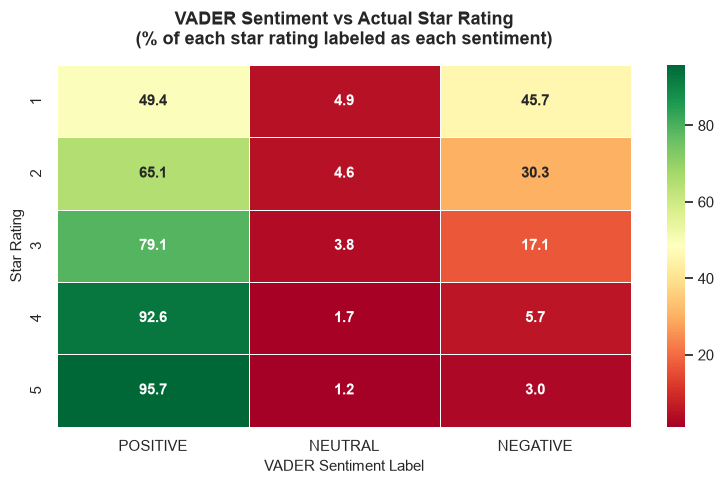

 Chart saved to outputs/!

INTERPRETATION:
─────────────────────────────────────────────
Green diagonal = VADER correct
Off-diagonal red = VADER mistakes

  1-star reviews: 49.4% labeled POSITIVE
  3-star reviews: 79.1% labeled POSITIVE
  5-star reviews: 95.7% labeled POSITIVE


In [15]:
# Cell 15 — Question 2: Does Sentiment Match Stars?

print("QUESTION 2: DOES SENTIMENT MATCH STAR RATINGS?")
print("=" * 55)

cross_tab = pd.crosstab(
    df_raw['Score'],
    df_raw['sentiment'],
    normalize='index'
)
cross_tab = cross_tab[['POSITIVE', 'NEUTRAL', 'NEGATIVE']]

print("\nCROSS TABULATION (row % of each star rating):")
print(cross_tab.round(3))

fig, ax = plt.subplots(figsize=(8, 5))

sns.heatmap(
    cross_tab * 100,        # convert proportions to percentages
    annot=True,
    fmt='.1f',
    cmap='RdYlGn',
    ax=ax,
    linewidths=0.5,
    linecolor='white',
    annot_kws={'size': 11, 'weight': 'bold'}
)

ax.set_title(
    'VADER Sentiment vs Actual Star Rating\n'
    '(% of each star rating labeled as each sentiment)',
    fontsize=13,
    fontweight='bold',
    pad=15
)

ax.set_xlabel('VADER Sentiment Label', fontsize=11)
ax.set_ylabel('Star Rating', fontsize=11)

plt.tight_layout()
plt.savefig(
    '../outputs/01_sentiment_vs_stars_heatmap.png',
    dpi=150,
    bbox_inches='tight'
)
plt.show()
print(" Chart saved to outputs/!")
print("\nINTERPRETATION:")
print("─" * 45)
print("Green diagonal = VADER correct")
print("Off-diagonal red = VADER mistakes")
print()

for star in [1, 3, 5]:
    row = cross_tab.loc[star]
    dominant = row.idxmax()
    pct = row.max() * 100
    print(f"  {star}-star reviews: "
          f"{pct:.1f}% labeled {dominant}")

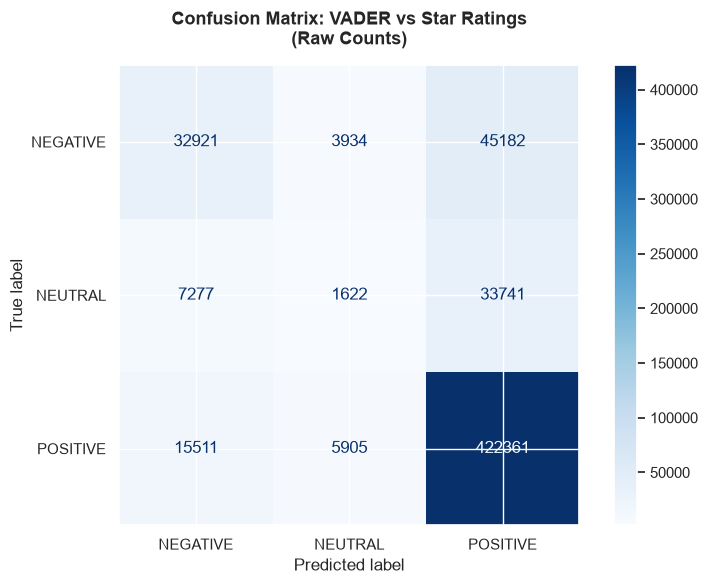

In [16]:
# Cell 16 — Confusion Matrix: Full Prediction Breakdown

# PURPOSE: Show all prediction errors in one grid
#          More detailed than Cell 15 heatmap
#          Cell 15 = percentages, Cell 16 = raw counts

from sklearn.metrics import confusion_matrix
from sklearn.metrics import ConfusionMatrixDisplay

cm = confusion_matrix(
    df_raw['rating_label'],
    df_raw['sentiment'],
    labels=['NEGATIVE', 'NEUTRAL', 'POSITIVE']
)

fig, ax = plt.subplots(figsize=(8, 6))

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=['NEGATIVE', 'NEUTRAL', 'POSITIVE']
)

disp.plot(
    cmap='Blues',
    ax=ax
)

ax.set_title(
    'Confusion Matrix: VADER vs Star Ratings\n'
    '(Raw Counts)',
    fontsize=13,
    fontweight='bold',
    pad=15
)

plt.tight_layout()

plt.savefig(
    '../outputs/02_confusion_matrix.png',
    dpi=150,
    bbox_inches='tight'
)

plt.show()

In [17]:
# Cell 17 — Mismatch Analysis: Where VADER Got It Wrong

# PURPOSE: Show actual reviews where VADER label
#          disagrees with the customer star rating
#          Supports the 1-star false positive finding

print("WHERE VADER DISAGREED WITH STAR RATINGS")
print("=" * 55)

mismatch = df_raw[
    df_raw['rating_label'] != df_raw['sentiment']
]

print(f"Total mismatches: {len(mismatch):,}")
print(f"Mismatch rate:    {len(mismatch)/len(df_raw)*100:.1f}%")
print(f"\nSample mismatches (first 20):")
print("─" * 55)

display(mismatch[
    ['Score', 'sentiment', 'vader_compound', 'Text']
].head(20))

WHERE VADER DISAGREED WITH STAR RATINGS
Total mismatches: 111,550
Mismatch rate:    19.6%

Sample mismatches (first 20):
───────────────────────────────────────────────────────


,Score,sentiment,vader_compound,Text
3,2,POSITIVE,0.4404,If you are looking for the secret ingredient i...
11,5,NEGATIVE,-0.7579,One of my boys needed to lose some weight and ...
12,1,POSITIVE,0.2960,My cats have been happily eating Felidae Plati...
16,2,POSITIVE,0.8743,I love eating them and they are good for watch...
25,5,NEUTRAL,0.0000,Product received is as advertised.<br /><br />...
47,3,POSITIVE,0.4404,"The flavors are good. However, I do not see a..."
49,3,POSITIVE,0.2363,This is the same stuff you can buy at the big ...
52,4,NEGATIVE,-0.8259,This wasn't in stock the last time I looked. I...
53,3,NEGATIVE,-0.3612,we're used to spicy foods down here in south t...
60,3,POSITIVE,0.4404,Watch your prices with this. While the assort...


PRODUCT-LEVEL SENTIMENT ANALYSIS
Total unique products: 74,258
Products with ≥20 reviews: 5,030
Reviews in analysis: 336,911

TOP 10 MOST NEGATIVE PRODUCTS:
─────────────────────────────────────────────────────────────────
  ProductId        Reviews    Neg%    Pos%    Avg★
─────────────────────────────────────────────────────────────────
  B000UJTZ8O            24   66.7%   33.3%    2.75★
  B004Z33GI6            35   65.7%   31.4%    1.83★
  B000FBMFDO            97   64.9%   34.0%    4.62★
  B00004RAMS            30   63.3%   36.7%    3.63★
  B00002N8SM            38   63.2%   36.8%    1.79★
  B000ZONYPE            27   63.0%   33.3%    3.89★
  B00004RAMX            25   60.0%   40.0%    3.64★
  B000VYD0MA            22   59.1%   40.9%    4.27★
  B000E1HW0G            21   57.1%   38.1%    1.57★
  B004H3N2LU            83   53.0%   45.8%    1.37★

TOP 10 MOST POSITIVE PRODUCTS:
─────────────────────────────────────────────────────────────────
  ProductId        Reviews    Pos%    Neg%

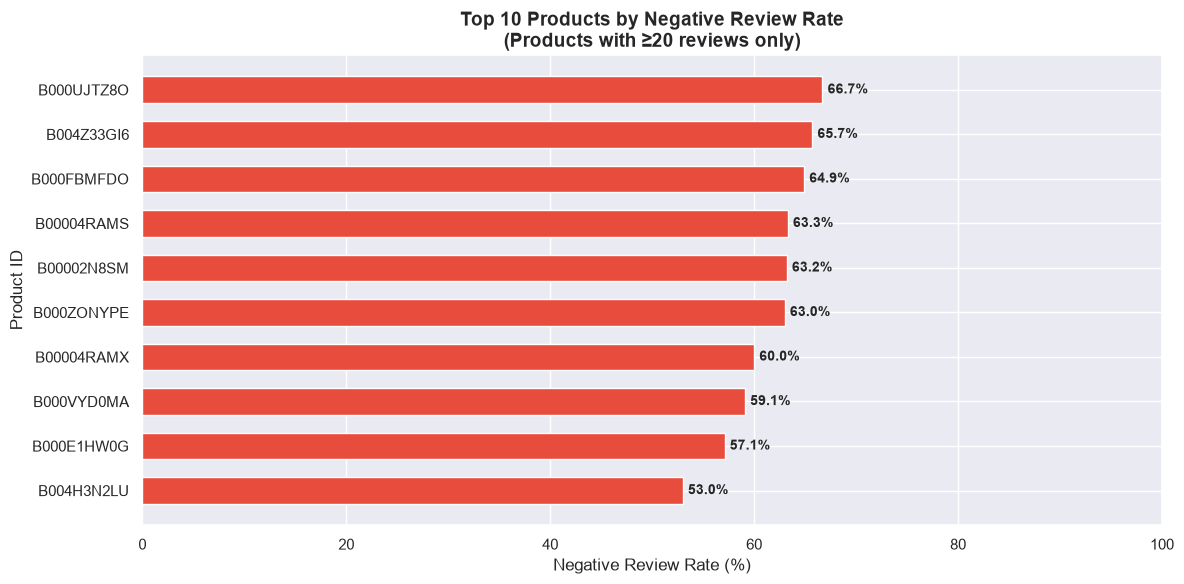

In [18]:
# Cell 18 — Product Analysis: Best and Worst Products

print("PRODUCT-LEVEL SENTIMENT ANALYSIS")
print("=" * 55)

# Step 1: Count reviews per product

product_counts = df_raw['ProductId'].value_counts()

print(f"Total unique products: {product_counts.shape[0]:,}")

# Step 2: Filter to products with enough reviews

MIN_REVIEWS = 20

qualifying_products = product_counts[
    product_counts >= MIN_REVIEWS
].index

print(f"Products with ≥{MIN_REVIEWS} reviews: "
      f"{len(qualifying_products):,}")

df_products = df_raw[
    df_raw['ProductId'].isin(qualifying_products)
].copy()

print(f"Reviews in analysis: {len(df_products):,}")

# Step 3: Calculate stats per product 

product_stats = df_products.groupby('ProductId').agg(
    total_reviews=('sentiment', 'count'),
    positive_count=('sentiment', lambda x: (x == 'POSITIVE').sum()),
    negative_count=('sentiment', lambda x: (x == 'NEGATIVE').sum()),
    neutral_count=('sentiment', lambda x: (x == 'NEUTRAL').sum()),
    avg_star_rating=('Score', 'mean'),
    avg_compound=('vader_compound', 'mean'),
    avg_subjectivity=('tb_subjectivity', 'mean')
).reset_index()

# Step 4: Calculate rates

product_stats['positive_rate'] = (
    product_stats['positive_count'] /
    product_stats['total_reviews'] * 100
).round(1)

product_stats['negative_rate'] = (
    product_stats['negative_count'] /
    product_stats['total_reviews'] * 100
).round(1)

product_stats['neutral_rate'] = (
    product_stats['neutral_count'] /
    product_stats['total_reviews'] * 100
).round(1)

# Step 5: Find worst products 

worst_products = product_stats.nlargest(10, 'negative_rate')

print("\nTOP 10 MOST NEGATIVE PRODUCTS:")
print("─" * 65)
print(f"  {'ProductId':<15} {'Reviews':>8} "
      f"{'Neg%':>7} {'Pos%':>7} {'Avg★':>7}")
print("─" * 65)

for _, row in worst_products.iterrows():
    print(f"  {row['ProductId']:<15} "
          f"{row['total_reviews']:>8.0f} "
          f"{row['negative_rate']:>6.1f}% "
          f"{row['positive_rate']:>6.1f}% "
          f"{row['avg_star_rating']:>7.2f}★")

# Step 6: Find best products 

best_products = product_stats.nlargest(
    10,
    'positive_rate'
)

print("\nTOP 10 MOST POSITIVE PRODUCTS:")
print("─" * 65)
print(f"  {'ProductId':<15} {'Reviews':>8} "
      f"{'Pos%':>7} {'Neg%':>7} {'Avg★':>7}")
print("─" * 65)

for _, row in best_products.iterrows():
    print(f"  {row['ProductId']:<15} "
          f"{row['total_reviews']:>8.0f} "
          f"{row['positive_rate']:>6.1f}% "
          f"{row['negative_rate']:>6.1f}% "
          f"{row['avg_star_rating']:>7.2f}★")

# Step 7: Overall stats 

print("\nPRODUCT-LEVEL SUMMARY STATISTICS:")
print("─" * 45)
print(f"  Average negative rate across products: "
      f"{product_stats['negative_rate'].mean():.1f}%")
print(f"  Average positive rate across products: "
      f"{product_stats['positive_rate'].mean():.1f}%")
print(f"  Most reviewed product has: "
      f"{product_stats['total_reviews'].max():.0f} reviews")
print(f"  Median reviews per product: "
      f"{product_stats['total_reviews'].median():.0f}")

# Step 8: Visualize top 10 worst products 

fig, ax = plt.subplots(figsize=(12, 6))

worst_sorted = worst_products.sort_values(
    'negative_rate',
    ascending=True
)

colors = [
    '#e74c3c' if rate > 50
    else '#f39c12' if rate > 30
    else '#e67e22'
    for rate in worst_sorted['negative_rate']
]

bars = ax.barh(
    worst_sorted['ProductId'],
    worst_sorted['negative_rate'],
    color=colors,
    edgecolor='white',
    height=0.6
)

for bar, value in zip(bars,
                       worst_sorted['negative_rate']):
    ax.text(
        bar.get_width() + 0.5,
        bar.get_y() + bar.get_height() / 2,
        f'{value:.1f}%',
        va='center',
        fontweight='bold',
        fontsize=10
    )

ax.set_title(
    'Top 10 Products by Negative Review Rate\n'
    f'(Products with ≥{MIN_REVIEWS} reviews only)',
    fontsize=14,
    fontweight='bold'
)
ax.set_xlabel('Negative Review Rate (%)', fontsize=12)
ax.set_ylabel('Product ID', fontsize=12)
ax.set_xlim(0, 100)

plt.tight_layout()
plt.savefig(
    '../outputs/03_worst_products.png',
    dpi=150,
    bbox_inches='tight'
)
plt.show()

SENTIMENT TREND OVER TIME (1999-2012)

YEARLY SENTIMENT PERCENTAGES:
───────────────────────────────────────────────────────
sentiment  POSITIVE  NEUTRAL  NEGATIVE
Year                                  
2003           93.2      0.8       6.1
2004           86.3      1.4      12.3
2005           87.9      4.3       7.7
2006           89.2      2.3       8.5
2007           89.7      2.4       7.9
2008           89.8      2.3       8.0
2009           89.6      2.2       8.2
2010           88.3      2.0       9.6
2011           87.8      1.9      10.3
2012           87.5      2.0      10.5


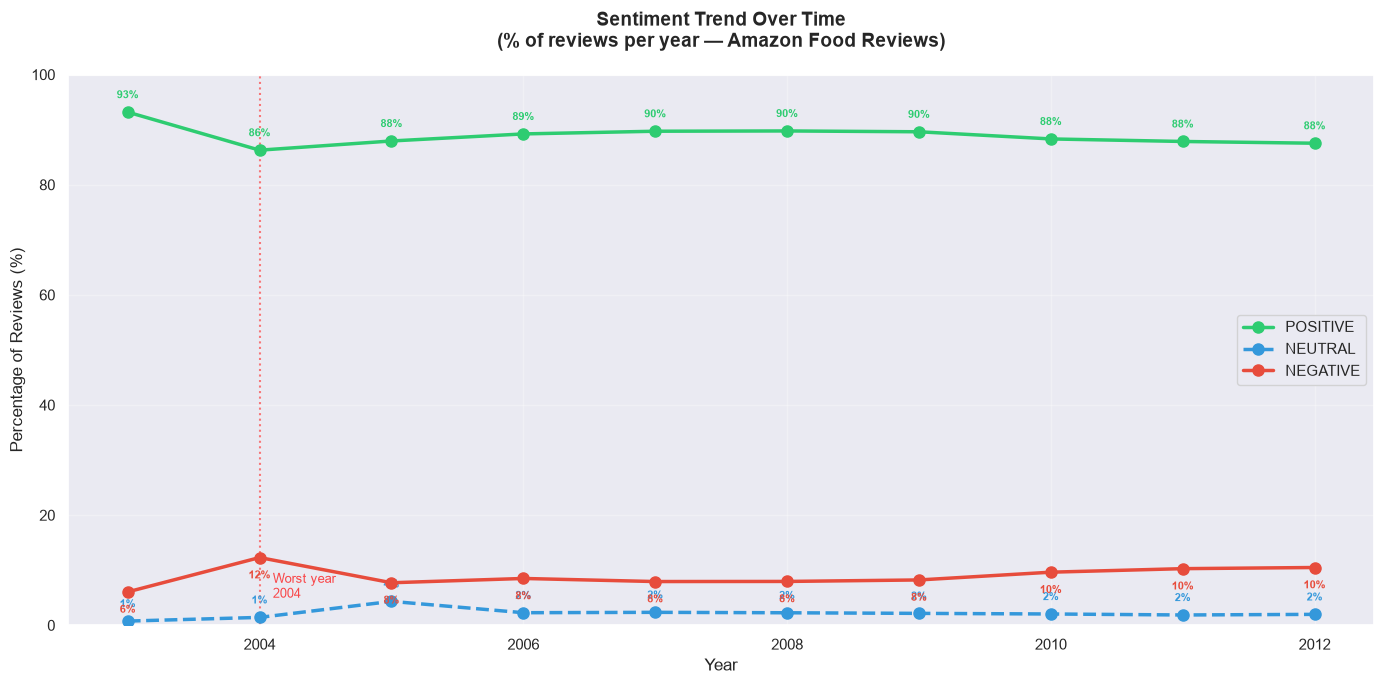


KEY FINDINGS:
─────────────────────────────────────────────
  Best year:  2003 → 93.2% positive
  Worst year: 2004 → 86.3% positive
  Peak negative year: 2004 → 12.3% negative

  Negative sentiment increased by 4.4% from 2003 to 2012
  Trend: sentiment is getting worse over time


In [19]:
# Cell 19 — Sentiment Trend Over Time

print("SENTIMENT TREND OVER TIME (1999-2012)")
print("=" * 55)

#  Step 1: Count sentiments per year 

yearly_sentiment = df_raw.groupby(
    ['Year', 'sentiment']
)['ProductId'].count().reset_index()

yearly_sentiment.columns = ['Year', 'sentiment', 'count']

#  Step 2: Calculate yearly totals 

yearly_totals = df_raw.groupby('Year').size()

#  Step 3: Filter years with enough reviews 

MIN_YEARLY_REVIEWS = 100

valid_years = yearly_totals[
    yearly_totals >= MIN_YEARLY_REVIEWS
].index

yearly_sentiment = yearly_sentiment[
    yearly_sentiment['Year'].isin(valid_years)
]

#  Step 4: Calculate percentages 

yearly_sentiment = yearly_sentiment.merge(
    yearly_totals.reset_index(),
    on='Year',
    how='left'
)

yearly_sentiment.columns = [
    'Year', 'sentiment', 'count', 'yearly_total'
]

yearly_sentiment['percentage'] = (
    yearly_sentiment['count'] /
    yearly_sentiment['yearly_total'] * 100
).round(2)

#  Step 5: Pivot to wide format 

yearly_pivot = yearly_sentiment.pivot(
    index='Year',
    columns='sentiment',
    values='percentage'
)

yearly_pivot = yearly_pivot[
    ['POSITIVE', 'NEUTRAL', 'NEGATIVE']
]

print("\nYEARLY SENTIMENT PERCENTAGES:")
print("─" * 55)
print(yearly_pivot.round(1).to_string())

#  Step 6: Line chart 

fig, ax = plt.subplots(figsize=(14, 7))

colors = {
    'POSITIVE': '#2ecc71',
    'NEGATIVE': '#e74c3c',
    'NEUTRAL': '#3498db'
}

line_styles = {
    'POSITIVE': '-',
    'NEGATIVE': '-',
    'NEUTRAL': '--'
}

for sentiment_label in ['POSITIVE', 'NEUTRAL', 'NEGATIVE']:
    if sentiment_label not in yearly_pivot.columns:
        continue

    ax.plot(
        yearly_pivot.index,
        yearly_pivot[sentiment_label],
        marker='o',
        linewidth=2.5,
        markersize=8,
        color=colors[sentiment_label],
        linestyle=line_styles[sentiment_label],
        label=sentiment_label,
        zorder=3
    )

    for year, pct in yearly_pivot[sentiment_label].items():
        if pd.isna(pct):
            continue

        ax.annotate(
            f'{pct:.0f}%',
            xy=(year, pct),
            xytext=(0, 10 if sentiment_label != 'NEGATIVE' else -15),
            textcoords='offset points',
            ha='center',
            fontsize=8,
            color=colors[sentiment_label],
            fontweight='bold'
        )

ax.set_title(
    'Sentiment Trend Over Time\n'
    '(% of reviews per year — Amazon Food Reviews)',
    fontsize=14,
    fontweight='bold',
    pad=20
)
ax.set_xlabel('Year', fontsize=12)
ax.set_ylabel('Percentage of Reviews (%)', fontsize=12)
ax.legend(fontsize=11, loc='center right')
ax.set_ylim(0, 100)
ax.grid(True, alpha=0.3)

if 'POSITIVE' in yearly_pivot.columns:
    worst_year = yearly_pivot['POSITIVE'].idxmin()
    worst_pct = yearly_pivot.loc[worst_year, 'POSITIVE']

    ax.axvline(
        x=worst_year,
        color='red',
        linestyle=':',
        alpha=0.5,
        linewidth=1.5
    )

    ax.text(
        worst_year + 0.1,
        5,
        f'Worst year\n{worst_year}',
        color='red',
        fontsize=9,
        alpha=0.7
    )

plt.tight_layout()
plt.savefig(
    '../outputs/04_sentiment_trend_over_time.png',
    dpi=150,
    bbox_inches='tight'
)
plt.show()

#  Step 7: Print key findings 

print("\nKEY FINDINGS:")
print("─" * 45)

if 'POSITIVE' in yearly_pivot.columns:
    best_year = yearly_pivot['POSITIVE'].idxmax()
    worst_year = yearly_pivot['POSITIVE'].idxmin()

    print(
        f"  Best year:  {best_year} → "
        f"{yearly_pivot.loc[best_year, 'POSITIVE']:.1f}% positive"
    )

    print(
        f"  Worst year: {worst_year} → "
        f"{yearly_pivot.loc[worst_year, 'POSITIVE']:.1f}% positive"
    )

if 'NEGATIVE' in yearly_pivot.columns:
    peak_neg_year = yearly_pivot['NEGATIVE'].idxmax()

    print(
        f"  Peak negative year: {peak_neg_year} → "
        f"{yearly_pivot.loc[peak_neg_year, 'NEGATIVE']:.1f}% negative"
    )

    first_year = yearly_pivot.index[0]
    last_year = yearly_pivot.index[-1]

    neg_change = (
        yearly_pivot.loc[last_year, 'NEGATIVE']
        - yearly_pivot.loc[first_year, 'NEGATIVE']
    )

    direction = "increased" if neg_change > 0 else "decreased"

    print(
        f"\n  Negative sentiment {direction} by "
        f"{abs(neg_change):.1f}% from "
        f"{first_year} to {last_year}"
    )

    print(
        f"  Trend: sentiment is getting "
        f"{'worse' if neg_change > 0 else 'better'} over time"
    )

REVIEW LENGTH vs SENTIMENT

LENGTH STATISTICS BY SENTIMENT:
───────────────────────────────────────────────────────
           avg_words  median_words  avg_chars  median_chars  review_count
sentiment                                                                
NEGATIVE        75.7          56.0      411.3         302.0         55709
NEUTRAL         41.3          31.0      222.7         166.0         11461
POSITIVE        81.7          57.0      443.9         306.0        501284

DIRECT COMPARISON:
─────────────────────────────────────────────
  POSITIVE reviews: 82 words avg
  NEUTRAL reviews:  41 words avg
  NEGATIVE reviews: 76 words avg

  Positive reviewers write 6 MORE words
  than negative reviewers on average.
  Interesting: happy customers elaborate more!


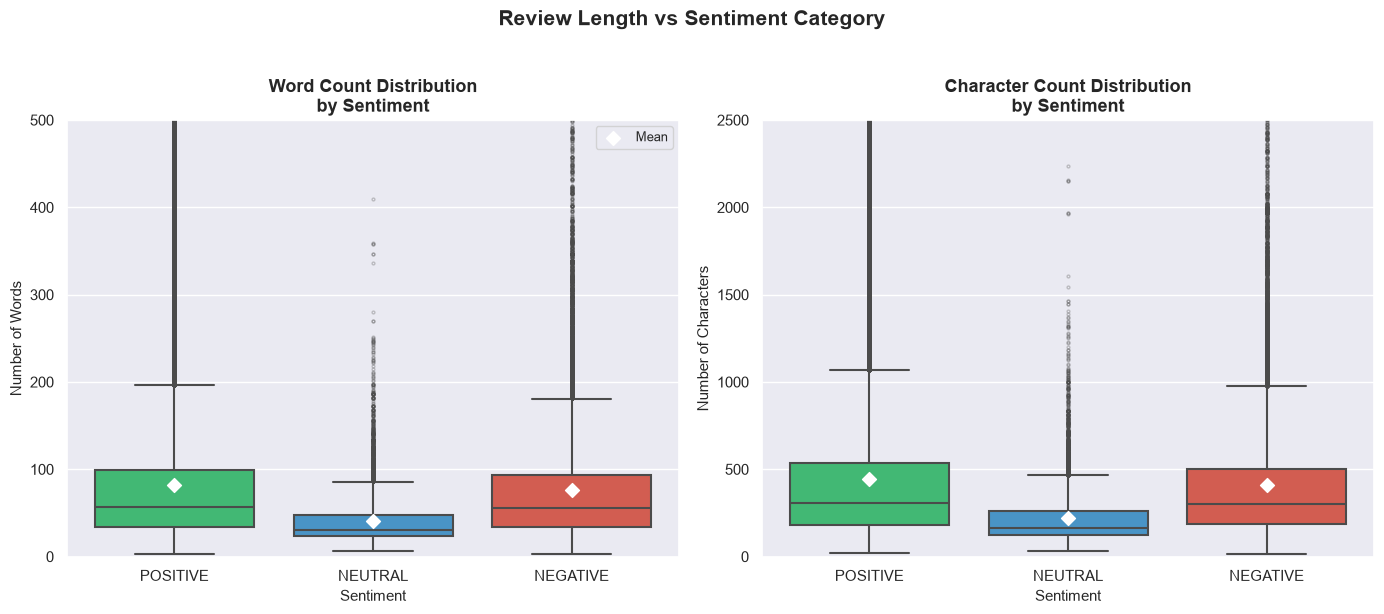


KEY INSIGHT:
─────────────────────────────────────────────
  Longest reviews:  POSITIVE (82 words avg)
  Shortest reviews: NEUTRAL (41 words avg)

  Implication for TF-IDF:
  POSITIVE reviews contain more words
  = richer vocabulary for keyword extraction
  = TF-IDF will find more specific keywords
  for this sentiment category


In [20]:
# Cell 20 — Review Length vs Sentiment

# PURPOSE: Do negative reviewers write longer reviews?

# BUSINESS VALUE:
# If negative reviews are longer:
#  They contain more detail about what went wrong
#  TF-IDF on long negative reviews = richer keywords
#  Product teams should prioritize reading them

print("REVIEW LENGTH vs SENTIMENT")
print("=" * 50)

#  Step 1: Summary statistics per sentiment 

length_stats = df_raw.groupby('sentiment').agg(
    avg_words=('word_count', 'mean'),
    median_words=('word_count', 'median'),
    avg_chars=('text_length', 'mean'),
    median_chars=('text_length', 'median'),
    review_count=('word_count', 'count')
).round(1)

print("\nLENGTH STATISTICS BY SENTIMENT:")
print("─" * 55)
print(length_stats.to_string())

#  Step 2: Direct comparison 

print("\nDIRECT COMPARISON:")
print("─" * 45)

neg_avg = df_raw[
    df_raw['sentiment'] == 'NEGATIVE'
]['word_count'].mean()

pos_avg = df_raw[
    df_raw['sentiment'] == 'POSITIVE'
]['word_count'].mean()

neu_avg = df_raw[
    df_raw['sentiment'] == 'NEUTRAL'
]['word_count'].mean()

print(f"  POSITIVE reviews: {pos_avg:.0f} words avg")
print(f"  NEUTRAL reviews:  {neu_avg:.0f} words avg")
print(f"  NEGATIVE reviews: {neg_avg:.0f} words avg")

diff = neg_avg - pos_avg

if diff > 0:
    print(f"\n  Negative reviewers write {diff:.0f} MORE words")
    print(f"  than positive reviewers on average.")
    print(f"  Confirms: unhappy customers explain more!")
else:
    diff = abs(diff)
    print(f"\n  Positive reviewers write {diff:.0f} MORE words")
    print(f"  than negative reviewers on average.")
    print(f"  Interesting: happy customers elaborate more!")

#  Step 3: Visualize with box plots 

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

sentiment_order = ['POSITIVE', 'NEUTRAL', 'NEGATIVE']

sns.boxplot(
    data=df_raw,
    x='sentiment',
    y='word_count',
    order=sentiment_order,
    palette={
        'POSITIVE': '#2ecc71',
        'NEUTRAL': '#3498db',
        'NEGATIVE': '#e74c3c'
    },
    ax=axes[0],
    linewidth=1.5,
    flierprops={
        'marker': 'o',
        'markersize': 2,
        'alpha': 0.3
    }
)

axes[0].set_title(
    'Word Count Distribution\nby Sentiment',
    fontsize=13,
    fontweight='bold'
)
axes[0].set_xlabel('Sentiment', fontsize=11)
axes[0].set_ylabel('Number of Words', fontsize=11)
axes[0].set_ylim(0, 500)

for i, sentiment in enumerate(sentiment_order):
    mean_val = df_raw[
        df_raw['sentiment'] == sentiment
    ]['word_count'].mean()

    axes[0].scatter(
        i,
        mean_val,
        marker='D',
        color='white',
        s=50,
        zorder=5,
        label='Mean' if i == 0 else ''
    )

axes[0].legend(fontsize=9)

sns.boxplot(
    data=df_raw,
    x='sentiment',
    y='text_length',
    order=sentiment_order,
    palette={
        'POSITIVE': '#2ecc71',
        'NEUTRAL': '#3498db',
        'NEGATIVE': '#e74c3c'
    },
    ax=axes[1],
    linewidth=1.5,
    flierprops={
        'marker': 'o',
        'markersize': 2,
        'alpha': 0.3
    }
)

axes[1].set_title(
    'Character Count Distribution\nby Sentiment',
    fontsize=13,
    fontweight='bold'
)
axes[1].set_xlabel('Sentiment', fontsize=11)
axes[1].set_ylabel('Number of Characters', fontsize=11)
axes[1].set_ylim(0, 2500)

for i, sentiment in enumerate(sentiment_order):
    mean_val = df_raw[
        df_raw['sentiment'] == sentiment
    ]['text_length'].mean()

    axes[1].scatter(
        i,
        mean_val,
        marker='D',
        color='white',
        s=50,
        zorder=5
    )

plt.suptitle(
    'Review Length vs Sentiment Category',
    fontsize=15,
    fontweight='bold',
    y=1.02
)

plt.tight_layout()

plt.savefig(
    '../outputs/05_review_length_vs_sentiment.png',
    dpi=150,
    bbox_inches='tight'
)

plt.show()

#  Step 4: Statistical insight 

print("\nKEY INSIGHT:")
print("─" * 45)

longest_sentiment = length_stats['avg_words'].idxmax()
shortest_sentiment = length_stats['avg_words'].idxmin()

print(
    f"  Longest reviews:  {longest_sentiment} "
    f"({length_stats.loc[longest_sentiment, 'avg_words']:.0f} words avg)"
)

print(
    f"  Shortest reviews: {shortest_sentiment} "
    f"({length_stats.loc[shortest_sentiment, 'avg_words']:.0f} words avg)"
)

print(f"\n  Implication for TF-IDF:")
print(f"  {longest_sentiment} reviews contain more words")
print(f"  = richer vocabulary for keyword extraction")
print(f"  = TF-IDF will find more specific keywords")
print(f"  for this sentiment category")

GENERATING WORD CLOUDS
Generating POSITIVE word cloud...
  Total words in corpus: 20,130,244
Generating NEGATIVE word cloud...
  Total words in corpus: 2,037,807
Generating NEUTRAL word cloud...
  Total words in corpus: 225,537


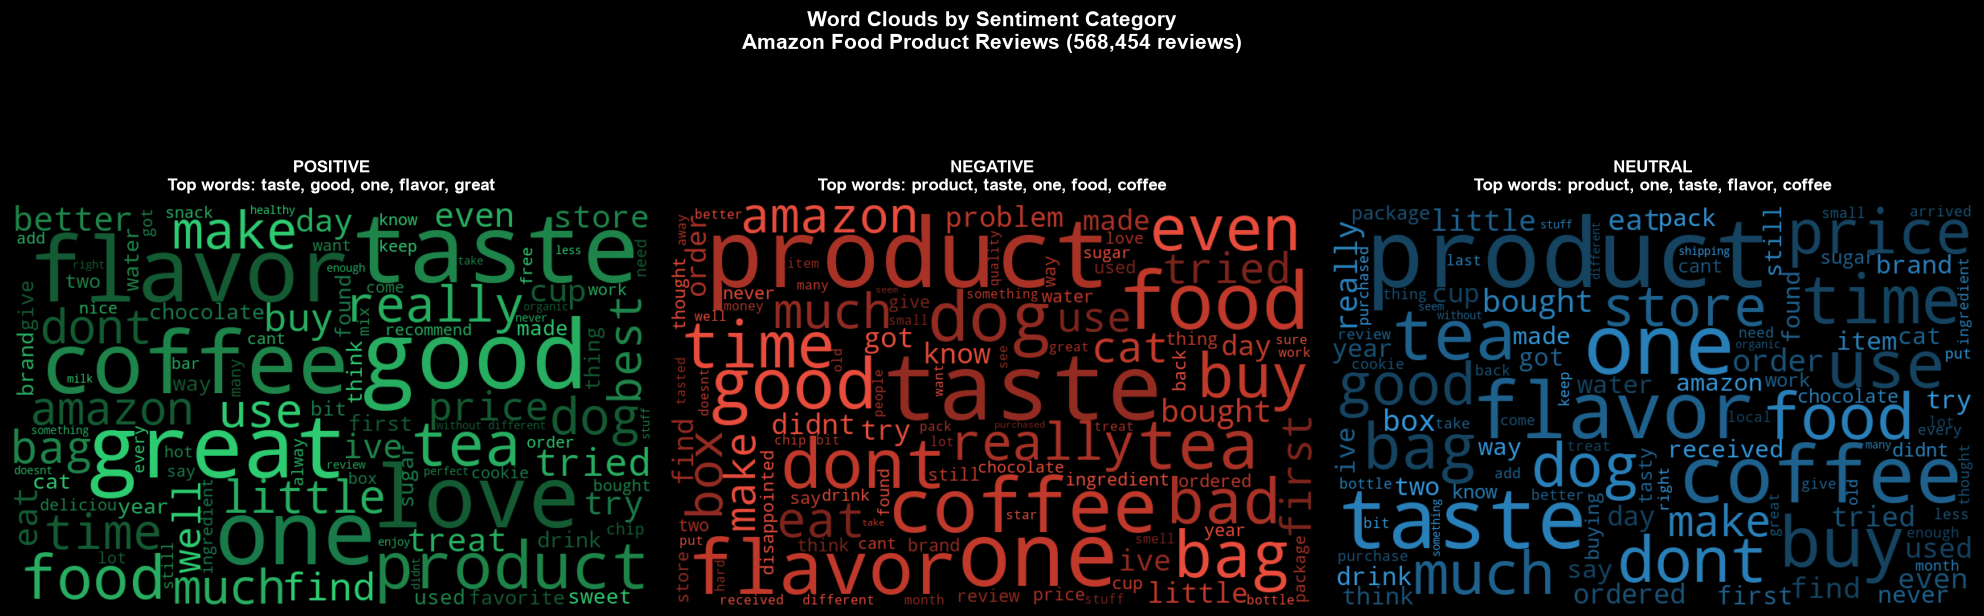


Combined word cloud saved!


In [21]:
# Cell 21 — WordCloud for Each Sentiment Category

print("GENERATING WORD CLOUDS")
print("=" * 50)


def positive_color_func(word, font_size, position,
                        orientation, random_state=None,
                        **kwargs):
    import random

    greens = [
        '#1a7a4a', '#2ecc71', '#27ae60',
        '#1e8449', '#145a32'
    ]

    return random.choice(greens)


def negative_color_func(word, font_size, position,
                        orientation, random_state=None,
                        **kwargs):
    import random

    reds = [
        '#c0392b', '#e74c3c', '#a93226',
        '#922b21', '#7b241c'
    ]

    return random.choice(reds)


def neutral_color_func(word, font_size, position,
                       orientation, random_state=None,
                       **kwargs):
    import random

    blues = [
        '#1a5276', '#2980b9', '#1f618d',
        '#154360', '#3498db'
    ]

    return random.choice(blues)


color_functions = {
    'POSITIVE': positive_color_func,
    'NEGATIVE': negative_color_func,
    'NEUTRAL': neutral_color_func
}

sentiment_labels = ['POSITIVE', 'NEGATIVE', 'NEUTRAL']

fig, axes = plt.subplots(1, 3, figsize=(20, 7))

for i, sentiment in enumerate(sentiment_labels):

    print(f"Generating {sentiment} word cloud...")

    sentiment_reviews = df_raw[
        df_raw['sentiment'] == sentiment
    ]['text_for_wordcloud']

    all_text = ' '.join(
        sentiment_reviews.dropna().astype(str)
    )

    word_count_in_corpus = len(all_text.split())

    print(f"  Total words in corpus: {word_count_in_corpus:,}")

    wordcloud = WordCloud(
        width=800,
        height=500,
        background_color='black',
        max_words=100,
        max_font_size=120,
        min_font_size=10,
        collocations=False,
        random_state=42
    ).generate(all_text)

    wordcloud.recolor(
        color_func=color_functions[sentiment]
    )

    axes[i].imshow(
        wordcloud,
        interpolation='bilinear'
    )

    axes[i].axis('off')

    word_frequencies = wordcloud.words_

    top_5 = list(word_frequencies.keys())[:5]
    top_5_str = ', '.join(top_5)

    axes[i].set_title(
        f'{sentiment}\nTop words: {top_5_str}',
        fontsize=12,
        fontweight='bold',
        color='white',
        pad=10
    )

    individual_path = (
        f'../outputs/wordcloud_{sentiment.lower()}.png'
    )

    wordcloud.to_file(individual_path)

plt.suptitle(
    'Word Clouds by Sentiment Category\n'
    'Amazon Food Product Reviews (568,454 reviews)',
    fontsize=15,
    fontweight='bold',
    color='white',
    y=1.02
)

fig.patch.set_facecolor('black')

plt.tight_layout()

plt.savefig(
    '../outputs/06_wordclouds_combined.png',
    dpi=150,
    bbox_inches='tight',
    facecolor='black'
)

plt.show()

print("\nCombined word cloud saved!")

TF-IDF PHRASE EXTRACTION (FINAL VERSION)
Total stopwords: 333
  POSITIVE: 5,000 reviews sampled
  NEGATIVE: 5,000 reviews sampled
  NEUTRAL: 5,000 reviews sampled

Vocabulary size: 5,000 phrases

TOP 15 PHRASES PER SENTIMENT:
───────────────────────────────────────────────────────

POSITIVE:
  'highly recommend'
  'gluten free'
  'grocery store'
  'peanut butter'
  'year old'
  'subscribe save'
  'dogs love'
  'years ago'
  'highly recommended'
  'high quality'
  'far best'
  'free shipping'
  'olive oil'
  'kids love'
  'right amount'

NEGATIVE:
  'waste money'
  'grocery store'
  'peanut butter'
  'expiration date'
  'throw away'
  'threw away'
  'local grocery'
  'stay away'
  'year old'
  'wasted money'
  'years ago'
  'read reviews'
  'quality control'
  'corn syrup'
  'right away'

NEUTRAL:
  'grocery store'
  'expiration date'
  'peanut butter'
  'year old'
  'local grocery'
  'ice cream'
  'grocery stores'
  'years ago'
  'coconut water'
  'local store'
  'less expensive'
  'ol

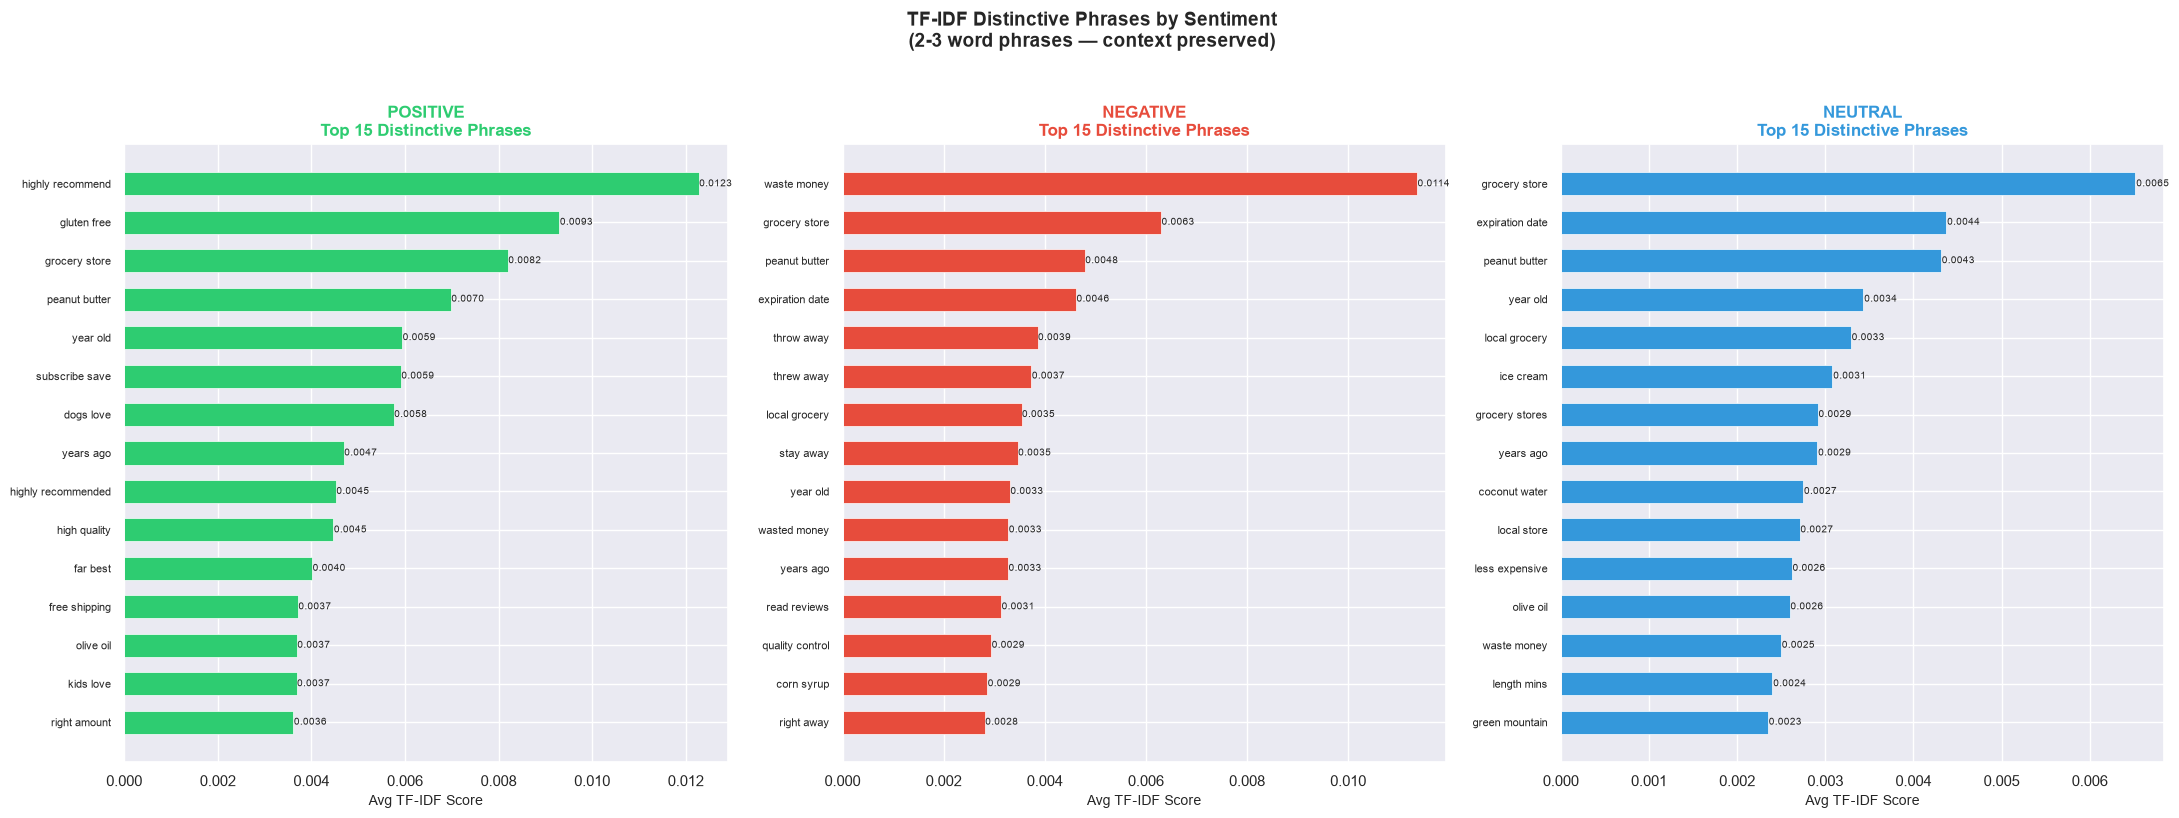


KEY FINDINGS:
─────────────────────────────────────────────

Most distinctive POSITIVE phrases:
  'highly recommend'
  'gluten free'
  'grocery store'
  'peanut butter'
  'year old'

Most distinctive NEGATIVE phrases:
  'waste money'
  'grocery store'
  'peanut butter'
  'expiration date'
  'throw away'

BUSINESS INSIGHT:
Monitor these specific phrases in new reviews.
A spike in negative phrases = early warning.
A rise in positive phrases = quality improving.


In [22]:
# Cell 22 — TF-IDF Keyword Extraction (Final Version)

# PURPOSE: Find PHRASES that distinctively define
#          each sentiment category

from sklearn.feature_extraction.text import TfidfVectorizer
import numpy as np

print("TF-IDF PHRASE EXTRACTION (FINAL VERSION)")
print("=" * 55)

#  Extended stopwords 

EXTENDED_STOPWORDS = ENGLISH_STOPWORDS.union({
    'product', 'products', 'food', 'foods',
    'coffee', 'tea', 'dog', 'cat', 'sugar',
    'chocolate', 'vanilla', 'flavor', 'flavors',
    'flavour', 'flavours', 'taste', 'tastes',
    'tasted', 'drink', 'drinking', 'drank',
    'eat', 'eating', 'ate', 'eaten',

    'buy', 'bought', 'buying', 'purchased',
    'order', 'ordered', 'ordering', 'orders',
    'use', 'used', 'using', 'uses',
    'try', 'tried', 'trying', 'tries',
    'get', 'got', 'getting', 'gets',
    'make', 'made', 'making', 'makes',
    'come', 'came', 'coming', 'comes',
    'know', 'knew', 'known', 'knowing',
    'think', 'thought', 'thinking',
    'find', 'found', 'finding',
    'give', 'gave', 'given', 'giving',
    'take', 'took', 'taken', 'taking',
    'want', 'wanted', 'wanting', 'wants',
    'need', 'needed', 'needing', 'needs',
    'look', 'looked', 'looking', 'looks',
    'seem', 'seemed', 'seems', 'seeming',

    'one', 'two', 'three', 'four', 'five',
    'really', 'very', 'quite', 'much', 'many',
    'little', 'lot', 'lots', 'bit', 'even',
    'still', 'also', 'well', 'back', 'way',
    'thing', 'things', 'time', 'times',
    'great', 'good', 'nice', 'bad',
    'like', 'just', 'would', 'could', 'should',
    'dont', 'doesnt', 'didnt', 'wasnt',
    'cant', 'couldnt', 'wouldnt', 'isnt',

    'every', 'always', 'never', 'ever',
    'something', 'anything', 'nothing',
    'someone', 'anyone', 'everyone',
})

print(f"Total stopwords: {len(EXTENDED_STOPWORDS)}")

#  Sample balanced reviews 

SAMPLE_SIZE = 5000
np.random.seed(42)

all_docs = []
all_labels = []

for sentiment in ['POSITIVE', 'NEGATIVE', 'NEUTRAL']:

    sentiment_reviews = df_raw[
        df_raw['sentiment'] == sentiment
    ]['text_for_wordcloud'].dropna()

    actual_size = min(
        SAMPLE_SIZE,
        len(sentiment_reviews)
    )

    sampled = sentiment_reviews.sample(
        n=actual_size,
        random_state=42
    ).tolist()

    all_docs.extend(sampled)
    all_labels.extend([sentiment] * len(sampled))

    print(f"  {sentiment}: {len(sampled):,} reviews sampled")

#  TF-IDF with phrases only 

vectorizer = TfidfVectorizer(
    max_features=5000,
    ngram_range=(2, 3),
    min_df=3,
    max_df=0.85,
    stop_words=list(EXTENDED_STOPWORDS),
    sublinear_tf=True
)

tfidf_matrix = vectorizer.fit_transform(all_docs)

feature_names = vectorizer.get_feature_names_out()

print(f"\nVocabulary size: {len(feature_names):,} phrases")

#  Extract top phrases per sentiment 

top_n = 15

keyword_results = {}

all_labels_array = np.array(all_labels)

print(f"\nTOP {top_n} PHRASES PER SENTIMENT:")
print("─" * 55)

for sentiment in ['POSITIVE', 'NEGATIVE', 'NEUTRAL']:

    mask = all_labels_array == sentiment

    sentiment_matrix = tfidf_matrix[mask]

    avg_scores = np.asarray(
        sentiment_matrix.mean(axis=0)
    ).flatten()

    top_indices = avg_scores.argsort()[-top_n:][::-1]

    top_words = [feature_names[i] for i in top_indices]
    top_scores = [avg_scores[i] for i in top_indices]

    keyword_results[sentiment] = list(
        zip(top_words, top_scores)
    )

    print(f"\n{sentiment}:")

    for phrase, score in keyword_results[sentiment]:
        print(f"  '{phrase}'")

#  Visualize 

fig, axes = plt.subplots(1, 3, figsize=(22, 8))

colors_map = {
    'POSITIVE': '#2ecc71',
    'NEGATIVE': '#e74c3c',
    'NEUTRAL': '#3498db'
}

for i, sentiment in enumerate([
    'POSITIVE',
    'NEGATIVE',
    'NEUTRAL'
]):

    phrases = [
        item[0]
        for item in keyword_results[sentiment]
    ]

    scores = [
        item[1]
        for item in keyword_results[sentiment]
    ]

    phrases_rev = phrases[::-1]
    scores_rev = scores[::-1]

    bars = axes[i].barh(
        phrases_rev,
        scores_rev,
        color=colors_map[sentiment],
        edgecolor='white',
        linewidth=0.5,
        height=0.6
    )

    for bar, score in zip(bars, scores_rev):

        axes[i].text(
            bar.get_width() + 0.00001,
            bar.get_y() + bar.get_height() / 2,
            f'{score:.4f}',
            va='center',
            fontsize=7
        )

    axes[i].set_title(
        f'{sentiment}\nTop {top_n} Distinctive Phrases',
        fontsize=12,
        fontweight='bold',
        color=colors_map[sentiment]
    )

    axes[i].set_xlabel(
        'Avg TF-IDF Score',
        fontsize=10
    )

    axes[i].tick_params(
        axis='y',
        labelsize=8
    )

plt.suptitle(
    'TF-IDF Distinctive Phrases by Sentiment\n'
    '(2-3 word phrases — context preserved)',
    fontsize=14,
    fontweight='bold',
    y=1.02
)

plt.tight_layout()

plt.savefig(
    '../outputs/07_tfidf_keywords.png',
    dpi=150,
    bbox_inches='tight'
)

plt.show()

#  Key findings 

print("\nKEY FINDINGS:")
print("─" * 45)

print("\nMost distinctive POSITIVE phrases:")

for phrase, score in keyword_results['POSITIVE'][:5]:
    print(f"  '{phrase}'")

print("\nMost distinctive NEGATIVE phrases:")

for phrase, score in keyword_results['NEGATIVE'][:5]:
    print(f"  '{phrase}'")

print("\nBUSINESS INSIGHT:")
print("Monitor these specific phrases in new reviews.")
print("A spike in negative phrases = early warning.")
print("A rise in positive phrases = quality improving.")

In [23]:
# Cell 23 — Interactive Plotly Dashboard

# PURPOSE: Combine all analysis into one
#          interactive HTML dashboard

import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import pandas as pd

print("BUILDING PLOTLY INTERACTIVE DASHBOARD")
print("=" * 55)

# Define consistent colors 

COLORS = {
    'POSITIVE': '#2ecc71',
    'NEGATIVE': '#e74c3c',
    'NEUTRAL': '#3498db'
}

# Create master figure with 5 subplots 

fig = make_subplots(
    rows=3,
    cols=2,
    subplot_titles=(
        'Sentiment Distribution',
        'Sentiment vs Star Rating',
        'Sentiment Trend Over Time',
        'Top 10 Most Negative Products',
        'Distinctive Phrases by Sentiment',
        ''
    ),
    specs=[
        [{'type': 'pie'}, {'type': 'bar'}],
        [{'type': 'scatter', 'colspan': 2}, None],
        [{'type': 'bar'}, {'type': 'bar'}],
    ],
    vertical_spacing=0.12,
    horizontal_spacing=0.1
)

# CHART 1 — Sentiment Distribution

sentiment_counts = df_raw['sentiment'].value_counts()

fig.add_trace(
    go.Pie(
        labels=sentiment_counts.index.tolist(),
        values=sentiment_counts.values.tolist(),
        marker=dict(
            colors=[
                COLORS[label]
                for label in sentiment_counts.index
            ],
            line=dict(color='white', width=2)
        ),
        textinfo='label+percent',
        hovertemplate=(
            '<b>%{label}</b><br>'
            'Count: %{value:,}<br>'
            'Percentage: %{percent}'
            '<extra></extra>'
        ),
        hole=0.3,
        showlegend=False,
    ),
    row=1,
    col=1
)

# CHART 2 — Sentiment vs Star Rating

star_sentiment = (
    df_raw.groupby(['Score', 'sentiment'])
    .size()
    .reset_index(name='count')
)

for sentiment in ['POSITIVE', 'NEGATIVE', 'NEUTRAL']:
    sentiment_data = star_sentiment[
        star_sentiment['sentiment'] == sentiment
    ]

    fig.add_trace(
        go.Bar(
            x=sentiment_data['Score'],
            y=sentiment_data['count'],
            name=sentiment,
            marker_color=COLORS[sentiment],
            legendgroup=sentiment,
            hovertemplate=(
                f'<b>{sentiment}</b><br>'
                'Star Rating: %{x}<br>'
                'Count: %{y:,}'
                '<extra></extra>'
            ),
            showlegend=True, 
        ),
        row=1,
        col=2
    )

# CHART 3 — Sentiment Trend Over Time

for sentiment in ['POSITIVE', 'NEUTRAL', 'NEGATIVE']:

    if sentiment not in yearly_pivot.columns:
        continue

    fig.add_trace(
        go.Scatter(
            x=yearly_pivot.index.tolist(),
            y=yearly_pivot[sentiment].tolist(),
            mode='lines+markers',
            name=sentiment,
            legendgroup=sentiment,
            line=dict(
                color=COLORS[sentiment],
                width=3
            ),
            marker=dict(
                size=8,
                color=COLORS[sentiment],
                line=dict(color='white', width=1)
            ),
            hovertemplate=(
                f'<b>{sentiment}</b><br>'
                'Year: %{x}<br>'
                'Percentage: %{y:.1f}%'
                '<extra></extra>'
            ),
            showlegend=False,
        ),
        row=2,
        col=1
    )

# CHART 4 — Top 10 Worst Products

worst_sorted = worst_products.sort_values(
    'negative_rate',
    ascending=True
)

fig.add_trace(
    go.Bar(
        y=worst_sorted['ProductId'].tolist(),
        x=worst_sorted['negative_rate'].tolist(),
        orientation='h',
        marker=dict(
            color=worst_sorted['negative_rate'].tolist(),
            colorscale='Reds',
            showscale=False,
            line=dict(color='white', width=0.5)
        ),
        hovertemplate=(
            '<b>%{y}</b><br>'
            'Negative Rate: %{x:.1f}%'
            '<extra></extra>'
        ),
        showlegend=False,
    ),
    row=3,
    col=1
)

# CHART 5 — TF-IDF Phrases Comparison

top_n_display = 8

for sentiment in ['POSITIVE', 'NEGATIVE']:

    phrases = [
        item[0]
        for item in keyword_results[sentiment][:top_n_display]
    ]

    scores = [
        item[1]
        for item in keyword_results[sentiment][:top_n_display]
    ]

    fig.add_trace(
        go.Bar(
            x=phrases,
            y=scores,
            name=f'{sentiment} phrases',
            marker_color=COLORS[sentiment],
            hovertemplate=(
                '<b>%{x}</b><br>'
                'TF-IDF Score: %{y:.4f}'
                '<extra></extra>'
            ),
            showlegend=False,
        ),
        row=3,
        col=2
    )

# Layout 

fig.update_layout(
    title=dict(
        text=(
            'Amazon Food Reviews — Sentiment Analysis Dashboard'
            '<br>'
            '<sup>568,454 reviews | 1999-2012 | '
            'VADER + TextBlob + TF-IDF</sup>'
        ),
        x=0.5,
        font=dict(size=18)
    ),
    height=1200,
    width=1400,
    showlegend=True,
    legend=dict(
        x=1.02,
        y=0.98,
        bgcolor='rgba(255,255,255,0.8)',
        bordercolor='lightgray',
        borderwidth=1
    ),
    paper_bgcolor='#f8f9fa',
    plot_bgcolor='white',
    font=dict(
        family='Arial, sans-serif',
        size=11
    ),
    barmode='group'
)

fig.update_xaxes(
    title_text='Negative Rate (%)',
    row=3,
    col=1
)

fig.update_yaxes(
    title_text='Product ID',
    row=3,
    col=1
)

fig.update_xaxes(
    title_text='Year',
    row=2,
    col=1
)

fig.update_yaxes(
    title_text='Percentage (%)',
    row=2,
    col=1
)

fig.update_xaxes(
    tickangle=30,
    row=3,
    col=2
)

fig.update_yaxes(
    title_text='TF-IDF Score',
    row=3,
    col=2
)

#  Save Dashboard 

dashboard_path = '../dashboard/sentiment_dashboard.html'

fig.write_html(
    dashboard_path,
    include_plotlyjs='cdn',
    full_html=True
)

print(f" Dashboard saved: {dashboard_path}")

print(
    f"   File size: "
    f"{os.path.getsize(dashboard_path) / 1024:.1f} KB"
)

fig.show()

print("\nDashboard is fully interactive!")
print("Open the HTML file in any browser to use it.")

BUILDING PLOTLY INTERACTIVE DASHBOARD
 Dashboard saved: ../dashboard/sentiment_dashboard.html
   File size: 14.2 KB



Dashboard is fully interactive!
Open the HTML file in any browser to use it.
